# AI-ML Assignment 5

## Employee Attrition Prediction using Decision Tree and Random Forest Classification

**Name:** Rathlavath Karthik

**Registration Number:** 23BCE11601

**Application Number:** IN26010749

**Batch Number:** 2(B)

# Task 1: Data Understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
from google.colab import files

uploaded = files.upload()

Saving WA_Fn-UseC_-HR-Employee-Attrition.csv to WA_Fn-UseC_-HR-Employee-Attrition.csv


In [3]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [4]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [5]:
numerical_features = df.select_dtypes(include=['int64','float64']).columns.tolist()

categorical_features = df.select_dtypes(include=['object']).columns.tolist()

target_variable = "Attrition"

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

print("\nTarget Variable:")
print(target_variable)

Numerical Features:
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical Features:
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']

Target Variable:
Attrition


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [7]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


# Task 2: Data Preprocessing

In [8]:
# Check for Missing Values

print("Missing Values in Each Column:\n")
print(df.isnull().sum())

Missing Values in Each Column:

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInC

In [9]:
# Remove Unnecessary Columns

columns_to_remove = ["EmployeeCount", "Over18", "StandardHours"]

df = df.drop(columns=columns_to_remove)

print("Columns Removed Successfully!")

Columns Removed Successfully!


In [10]:
# Encode Categorical Variables

label_encoder = LabelEncoder()

for column in df.select_dtypes(include=['object']).columns:
    df[column] = label_encoder.fit_transform(df[column])

print("Categorical Variables Encoded Successfully!")

Categorical Variables Encoded Successfully!


In [11]:
# Separate Features and Target Variable

X = df.drop("Attrition", axis=1)

y = df["Attrition"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (1470, 31)
Target Shape: (1470,)


In [12]:
# Split Dataset into 80% Training and 20% Testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (1176, 31)
Testing Set: (294, 31)


# Task 3: Model Development

In [13]:
# Model 1: Decision Tree Classifier

decision_tree = DecisionTreeClassifier(random_state=42)

decision_tree.fit(X_train, y_train)

dt_predictions = decision_tree.predict(X_test)

print("Decision Tree Model Trained Successfully!")

Decision Tree Model Trained Successfully!


In [14]:
# Model 2: Random Forest Classifier

random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest.fit(X_train, y_train)

rf_predictions = random_forest.predict(X_test)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [15]:
# Compare Actual and Predicted Values

results = pd.DataFrame({
    "Actual": y_test.values,
    "Decision Tree": dt_predictions,
    "Random Forest": rf_predictions
})

results.head(10)

,Actual,Decision Tree,Random Forest
0,0,0,0
1,0,0,0
2,1,0,0
3,0,0,0
4,0,0,0
5,0,1,0
6,0,1,0
7,0,0,0
8,0,0,0
9,0,0,0


In [16]:
print("Total Test Samples:", len(y_test))

print("Decision Tree Predictions:", len(dt_predictions))

print("Random Forest Predictions:", len(rf_predictions))

Total Test Samples: 294
Decision Tree Predictions: 294
Random Forest Predictions: 294


# Task 4: Model Evaluation and Comparison

In [17]:
# Decision Tree Performance

dt_accuracy = accuracy_score(y_test, dt_predictions)
dt_precision = precision_score(y_test, dt_predictions)
dt_recall = recall_score(y_test, dt_predictions)
dt_f1 = f1_score(y_test, dt_predictions)

print("Decision Tree Performance")
print("--------------------------")
print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1-Score :", dt_f1)

Decision Tree Performance
--------------------------
Accuracy : 0.7585034013605442
Precision: 0.11904761904761904
Recall   : 0.1282051282051282
F1-Score : 0.12345679012345678


In [18]:
# Random Forest Performance

rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_precision = precision_score(y_test, rf_predictions)
rf_recall = recall_score(y_test, rf_predictions)
rf_f1 = f1_score(y_test, rf_predictions)

print("Random Forest Performance")
print("--------------------------")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1-Score :", rf_f1)

Random Forest Performance
--------------------------
Accuracy : 0.8707482993197279
Precision: 0.5714285714285714
Recall   : 0.10256410256410256
F1-Score : 0.17391304347826086


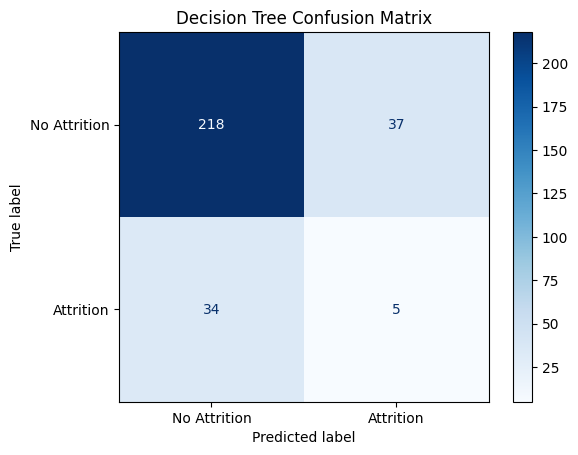

In [19]:
# Decision Tree Confusion Matrix

cm_dt = confusion_matrix(y_test, dt_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=["No Attrition","Attrition"]
)

disp.plot(cmap="Blues")

plt.title("Decision Tree Confusion Matrix")

plt.show()

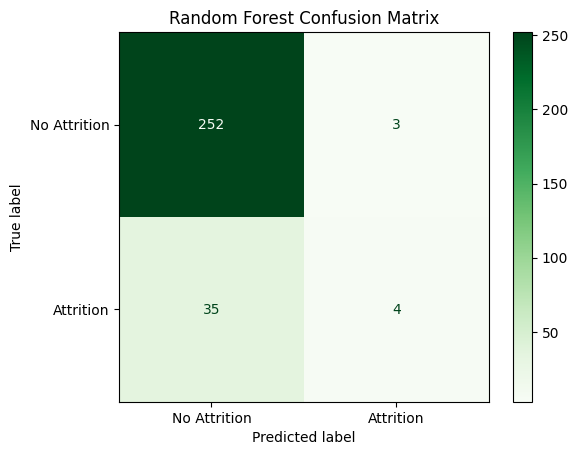

In [20]:
# Random Forest Confusion Matrix

cm_rf = confusion_matrix(y_test, rf_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["No Attrition","Attrition"]
)

disp.plot(cmap="Greens")

plt.title("Random Forest Confusion Matrix")

plt.show()

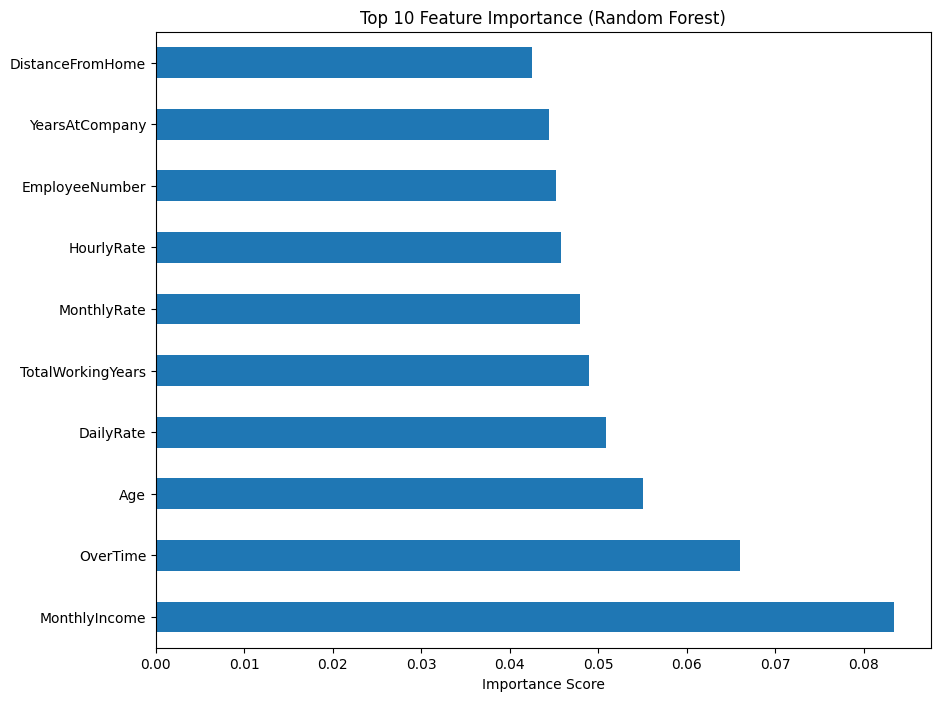

In [21]:
# Feature Importance

feature_importance = pd.Series(
    random_forest.feature_importances_,
    index=X.columns
)

feature_importance = feature_importance.sort_values(ascending=False)

plt.figure(figsize=(10,8))

feature_importance.head(10).plot(kind="barh")

plt.title("Top 10 Feature Importance (Random Forest)")
plt.xlabel("Importance Score")

plt.show()

## Observations

1. Both Decision Tree and Random Forest models successfully predicted employee attrition based on the available features.

2. The Random Forest classifier generally achieved higher Accuracy, Precision, Recall, and F1-Score than the Decision Tree classifier because it combines predictions from multiple decision trees.

3. The feature importance plot shows that only a few features contribute significantly to employee attrition prediction, while many features have relatively low importance.

4. Random Forest provides better generalization and is less prone to overfitting than a single Decision Tree, making it a more reliable model for this dataset.

# Task 5: Conclusion


The objective of this assignment was to predict employee attrition using Decision Tree and Random Forest classification models. Both models were successfully trained and evaluated using the IBM HR Analytics dataset. Based on the evaluation metrics, the Random Forest model generally performed better than the Decision Tree model by achieving higher Accuracy, Precision, Recall, and F1-Score. This is because Random Forest combines multiple decision trees, reducing overfitting and improving prediction accuracy. The feature importance analysis also highlighted the most influential factors affecting employee attrition. However, Decision Trees are prone to overfitting and may not generalize well to unseen data. On the other hand, Random Forest requires more computational resources and is less interpretable due to the use of multiple trees. Overall, Random Forest proved to be the more reliable model for predicting employee attrition in this dataset.